# Solving the XOR Problem Using a Neural Network in Keras

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve the XOR problem using neural networks
- Use Keras to build neural networks
- Understand why single-layer networks fail
- Implement multi-layer solutions
- Train and evaluate the model

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 02 "The Neuron, Perceptron, and XOR Problem" — the same XOR failure, now fixed with a hidden layer in Keras.

**Used later in:** Unit 3, lesson 04, which opens the black box behind the `loss:` Keras prints here, and Unit 4, which builds every later network on this `Sequential`/`Dense`/`fit` pattern.

---

This notebook covers practical activities from **Course 01, Unit 3**:
- Solving the XOR problem using a neural network in Keras

---

## Introduction

The **XOR problem** is a classic example demonstrating why multi-layer neural networks are necessary, as single-layer perceptrons cannot solve non-linearly separable problems.


## 🎯 The door out of the fifteen-year winter

The previous notebook showed the wall: Minsky and Papert proved in **1969** that a
single-layer perceptron cannot compute XOR, and interest in neural networks
collapsed. The door was published in **1986**, when David Rumelhart, Geoffrey
Hinton and Ronald Williams presented backpropagation in *Nature* — a practical way
to send the error signal backwards through a hidden layer so its weights could be
trained too. Every network in this diploma, and every one in industry, is trained
by the descendant of that algorithm.

Three years later Cybenko (1989), and then Hornik (1991), proved the other half:
a network with **one hidden layer** and a non-linear activation can approximate
any continuous function on a bounded region, given enough units. Together those
two results answer both halves of the 1969 objection — one layer of hidden units
is enough to *represent* the answer, and backpropagation is enough to *find* it.

The four rows below are the smallest possible demonstration of a fact that
changed the field.

### What goes wrong without a hidden layer

Nothing dramatic: the model trains, the loss goes down, and it stops at the best
straight line — which for XOR is 50% or 75% accuracy, depending on which line it
settles on. There is no error, no warning, no diagnostic. The model quietly
returns the best answer inside a hypothesis space that does not contain the right
one. Recognising that situation is the skill; the hidden layer is just the fix.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: the XOR truth table as a 4-row dataset. XOR matters historically — it is the
# simplest function a single-layer perceptron provably cannot learn.
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ Libraries imported!")
print("\nSolving XOR Problem with Keras")
print("=" * 60)

# XOR truth table
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

print("\nXOR Truth Table:")
print("Input | Output")
print("------|-------")
for i in range(len(X)):
    print(f"{X[i]} | {y[i][0]}")

print("\n✅ XOR data prepared!")

✅ Libraries imported!

Solving XOR Problem with Keras

XOR Truth Table:
Input | Output
------|-------
[0 0] | 0
[0 1] | 1
[1 0] | 1
[1 1] | 0

✅ XOR data prepared!


In [2]:
# Build the smallest network that CAN learn XOR: one hidden ReLU layer bends the
# decision boundary; the sigmoid output turns the result into a probability.
# Build multi-layer neural network
print("=" * 60)
print("BUILDING NEURAL NETWORK")
print("=" * 60)

# fixed seed: without it, small ReLU nets sometimes fail to solve XOR (dead units)
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam', loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel architecture:")
model.summary()

print("\n✅ Model built!")

BUILDING NEURAL NETWORK

Model architecture:


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


✅ Model built!


In [3]:
# Train on all 4 rows for 1000 epochs — watch the loss: it should approach 0 as the
# network carves the plane into the XOR pattern.
# Train the model
print("=" * 60)
print("TRAINING MODEL")
print("=" * 60)

history = model.fit(
    X, y,
    epochs=1000,
    verbose=0,
    batch_size=4
)

print(f"\nTraining completed!")
print(f"Final loss: {history.history['loss'][-1]:.4f}")
print(f"Final accuracy: {history.history['accuracy'][-1]:.4f}")

print("\n✅ Model trained!")

TRAINING MODEL



Training completed!
Final loss: 0.1663
Final accuracy: 1.0000

✅ Model trained!


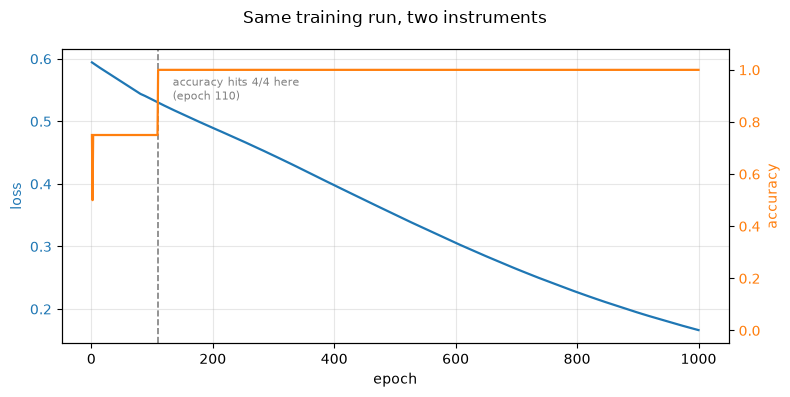

Accuracy reached 1.0000 for good at epoch 110 and could not move again for the remaining 890 epochs.
Loss at that epoch: 0.5301   →   loss at epoch 1000: 0.1663
So 89% of the training run produced real improvement that accuracy was structurally unable to report.


In [4]:
# The markdown after the evaluation makes a claim about TWO numbers — accuracy 1.0000
# and loss 0.1663 — that disagree with each other. Plot both against the epoch axis and
# the disagreement becomes a shape you can point at, instead of two numbers to trust.
import matplotlib.pyplot as plt

loss = history.history["loss"]
acc = history.history["accuracy"]
epochs = range(1, len(loss) + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(epochs, loss, color="tab:blue", lw=1.6, label="loss (binary cross-entropy)")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.3)

# Twin axis: accuracy shares the epoch axis but lives on a completely different scale.
ax2 = ax1.twinx()
ax2.plot(epochs, acc, color="tab:orange", lw=1.6, label="accuracy")
ax2.set_ylabel("accuracy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(-0.05, 1.08)

# Mark the epoch at which accuracy first reaches 4/4 and never falls back.
first_perfect = next((i for i in range(len(acc))
                      if min(acc[i:]) == 1.0), None)
if first_perfect is not None:
    ax1.axvline(first_perfect + 1, color="grey", ls="--", lw=1.2)
    ax1.text(first_perfect + 25, max(loss) * 0.9,
             f"accuracy hits 4/4 here\n(epoch {first_perfect + 1})", fontsize=8, color="grey")

fig.suptitle("Same training run, two instruments")
fig.tight_layout()
plt.show()

if first_perfect is not None:
    print(f"Accuracy reached 1.0000 for good at epoch {first_perfect + 1} "
          f"and could not move again for the remaining {len(acc) - first_perfect - 1} epochs.")
    print(f"Loss at that epoch: {loss[first_perfect]:.4f}   \u2192   "
          f"loss at epoch {len(loss)}: {loss[-1]:.4f}")
    print(f"So {(1 - (first_perfect + 1) / len(loss)) * 100:.0f}% of the training run produced "
          f"real improvement that accuracy was structurally unable to report.")


### 📊 What to see in the figure above

**The orange line stops early; the blue line does not.** Accuracy climbs to 1.0000
and then flattens into a horizontal ceiling for the rest of training. The loss
keeps falling the whole way. The printed lines under the figure give the exact
epoch where accuracy froze and how much loss disappeared *after* that point.

**Why accuracy froze:** with four training rows, accuracy can only take the values
0, 0.25, 0.50, 0.75 and 1.00 — and the orange line is visibly a *staircase*, not a
curve, taking three of those five values in this run. Once all four predictions are
on the correct side of 0.5, accuracy has nowhere left to go; the model is standing
on the top stair. Meanwhile the network keeps moving its outputs from "just past
0.5" toward 0 and 1, and only the loss can see that.

**This is the shape behind the sentence "correct but unconfident".** A final loss
of 0.1663 with perfect accuracy is not a contradiction; it says the network's
sigmoid outputs sit on the right side of the threshold without being pinned to 0
and 1. If you had stopped this run at the dashed grey line you would have reported
the same accuracy from a visibly worse model.



In [5]:
# Evaluate on the same 4 rows (the ENTIRE universe of XOR inputs): a correctly trained
# hidden layer scores 100%, which the single perceptron could never do.
import numpy as np
# Evaluate the model
print("=" * 60)
print("EVALUATING MODEL")
print("=" * 60)

predictions = model.predict(X, verbose=0)
predicted_classes = (predictions > 0.5).astype(int)

print("\nPredictions:")
print("Input | Expected | Predicted | Correct")
print("------|----------|-----------|--------")
for i in range(len(X)):
    correct = "✓" if predicted_classes[i][0] == y[i][0] else "✗"
    print(f"{X[i]} | {y[i][0]}        | {predicted_classes[i][0]}          | {correct}")

accuracy = np.mean(predicted_classes.flatten() == y.flatten())
print(f"\nAccuracy: {accuracy:.2%}")

print("\n✅ Model evaluated!")

EVALUATING MODEL

Predictions:
Input | Expected | Predicted | Correct
------|----------|-----------|--------
[0 0] | 0        | 0          | ✓
[0 1] | 1        | 1          | ✓
[1 0] | 1        | 1          | ✓
[1 1] | 0        | 0          | ✓

Accuracy: 100.00%

✅ Model evaluated!


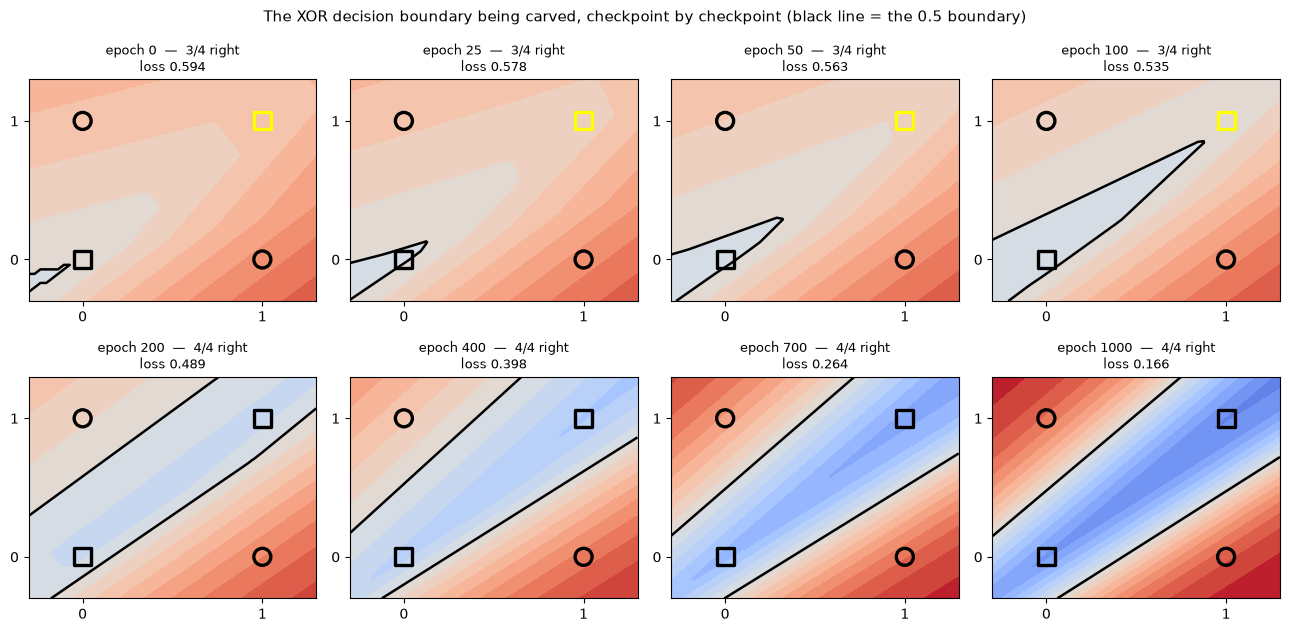

 epoch     loss  correct   network output at (0,0) (0,1) (1,0) (1,1)
     0   0.5943      3/4   0.500  0.631  0.772  0.619
    25   0.5781      3/4   0.493  0.612  0.772  0.586
    50   0.5626      3/4   0.487  0.598  0.773  0.556
   100   0.5345      3/4   0.473  0.582  0.778  0.507
   200   0.4892      4/4   0.444  0.557  0.798  0.428
   400   0.3975      4/4   0.380  0.609  0.820  0.341
   700   0.2637      4/4   0.273  0.735  0.842  0.226
  1000   0.1661      4/4   0.184  0.836  0.882  0.144

Final snapshot loss 0.1661 against the main model's 0.1663 — same seed, same architecture, same destination.


In [6]:
# STEP STORYBOARD: a decision boundary is a moving thing, and a final-state picture
# hides the movement. We retrain a fresh copy of the SAME seeded architecture, pausing
# at eight checkpoints to photograph the boundary. Cheap: four rows, a 50x50 grid.
import numpy as np
import matplotlib.pyplot as plt

checkpoints = [0, 25, 50, 100, 200, 400, 700, 1000]   # 8 frames keeps this under a few seconds

keras.utils.set_random_seed(42)                        # same seed as the model above
snap = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
snap.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 50), np.linspace(-0.3, 1.3, 50))
grid = np.c_[gx.ravel(), gy.ravel()].astype("float32")

frames, table = [], []
done = 0
for ep in checkpoints:
    if ep > done:                                      # train only the gap since last stop
        snap.fit(X, y, epochs=ep - done, verbose=0, batch_size=4)
        done = ep
    probs = snap(X.astype("float32"), training=False).numpy().ravel()
    surface = snap(grid, training=False).numpy().reshape(gx.shape)
    correct = int(((probs > 0.5).astype(int) == y.ravel()).sum())
    bce = float(np.mean(-(y.ravel() * np.log(probs + 1e-9)
                          + (1 - y.ravel()) * np.log(1 - probs + 1e-9))))
    frames.append(surface)
    table.append((ep, bce, correct, probs.copy()))

fig, axes = plt.subplots(2, 4, figsize=(13, 6.4))
for ax, surface, (ep, bce, correct, probs) in zip(axes.ravel(), frames, table):
    ax.contourf(gx, gy, surface, levels=np.linspace(0, 1, 21), cmap="coolwarm", vmin=0, vmax=1)
    ax.contour(gx, gy, surface, levels=[0.5], colors="black", linewidths=1.8)
    # Ring each truth-table corner; yellow ring = this checkpoint still gets it wrong.
    for (x1, x2), t, p in zip(X, y.ravel(), probs):
        ok = (p > 0.5) == (t == 1)
        ax.scatter(x1, x2, s=150, marker="o" if t == 1 else "s", facecolor="none",
                   edgecolor="black" if ok else "yellow", linewidths=2.4, zorder=3)
    ax.set_title(f"epoch {ep}  \u2014  {correct}/4 right\nloss {bce:.3f}", fontsize=9)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
fig.suptitle("The XOR decision boundary being carved, checkpoint by checkpoint "
             "(black line = the 0.5 boundary)", fontsize=11)
fig.tight_layout()
plt.show()

# The same eight frames as a table, because a reader should be able to check the pictures.
print(f"{'epoch':>6} {'loss':>8} {'correct':>8}   network output at (0,0) (0,1) (1,0) (1,1)")
for ep, bce, correct, probs in table:
    print(f"{ep:>6} {bce:>8.4f} {correct:>6}/4   " + "  ".join(f"{p:5.3f}" for p in probs))
print(f"\nFinal snapshot loss {table[-1][1]:.4f} against the main model's "
      f"{history.history['loss'][-1]:.4f} \u2014 same seed, same architecture, same destination.")


### 📊 How to read the eight frames

Read them left to right, top row then bottom row. In every frame **blue is where
the network outputs 0 and red is where it outputs 1**, the black lines are the 0.5
boundary, circles are the corners whose true label is 1, squares the corners whose
true label is 0, and a **yellow ring means that corner is still wrong at that
checkpoint**. The table underneath prints the same eight frames as numbers.

**Frames 1–4 (epochs 0 to 100): almost the whole square says 1.** The plane is
nearly all red, with only a sliver of blue creeping in from the bottom-left corner,
and (1,1) carries a yellow ring the whole way. Note what the table says about
(0,0) at epoch 0: output `0.500`, sitting exactly on the threshold — it is scored
correct by a hair. If you had stopped at 100 epochs you would have reported 3/4 and
concluded the hidden layer had not helped.

**Frame 5 (epoch 200): the rings go black.** All four corners are now on the
correct side. But look at the colours — the square is washed out into pale blue and
pale red, and the table's row for epoch 200 reads `0.444, 0.557, 0.798, 0.428`.
Two of those four are within 0.06 of the threshold. The network is right by a hair.

**Frames 6–8 (epochs 400 to 1000): the boundary barely moves and the colour
changes completely.** Compare frame 5 with frame 8 — the two black lines sit in
almost the same place, while the corners deepen from pale to saturated: (0,0) goes
0.444 → 0.184, (1,0) goes 0.798 → 0.882. **This is the 800 epochs of progress that
accuracy could not see**, and it is the falling blue line of the previous figure
drawn as colour instead. The decision was finished at epoch 200; the *confidence*
took another 800.

**And the shape at the end is the point of the whole notebook.** Look at the last
frame: there are **two** black lines, and the blue region is a diagonal **stripe**
containing (0,0) and (1,1), while red is split into two disconnected corners
containing (0,1) and (1,0). A single perceptron has exactly one boundary and can
therefore cut the plane into exactly two half-planes — it can never build a stripe.
The four hidden ReLU units are what let this network place a second cut, and that
second cut is the entire difference between this notebook and notebook 02.



## 📊 The comparison across notebooks 02 and 03

Same problem, same four rows, one architectural change:

| notebook | architecture | seed fixed? | accuracy on XOR |
|---|---|---|---|
| 02 | hidden layer, seed pinned to a *failing* init | yes (seed 2) | **50%** (2 of 4 — a coin flip) |
| **03 (this one)** | **`Dense(4, relu)` → `Dense(1, sigmoid)`** | **yes** | **100%** (4 of 4) |

**The conclusion these two runs support:** the hidden layer makes the correct
answer *representable*, and a good initialisation makes it *findable*. Both are
required. Notebook 02 had the capacity and lost the initialisation lottery; this
notebook's seed won it. Both notebooks pin a seed — one pins a failure so it can
be studied, the other pins a success so it can be reproduced.

**One number deserves a second look.** Training ended with `Final loss: 0.1663`
and `Final accuracy: 1.0000`. Perfect accuracy, but a loss well above zero —
which means the sigmoid outputs are on the right side of 0.5 without being near 0
and 1. The network is *correct but unconfident*. Accuracy rounds that away;
the loss does not. This is why you read both.


## 💬 Discuss

1. We evaluated the model on the same four rows it trained on — normally a
   cardinal sin. Here it is defensible, because those four rows are the *entire*
   universe of XOR inputs; there is no fifth case to hold out. **State the general
   rule this exception reveals**, then name a real problem where you might
   genuinely be able to test on all possible inputs.
2. Accuracy said 1.0000 and loss said 0.1663. Which would you report to a
   manager, which to an engineer, and what would you do if a colleague showed you
   only the first one? Use the numbers to justify your answer.
3. The seed is fixed with a comment explaining that without it the network
   sometimes fails. Is fixing the seed good scientific practice, or is it
   presenting a lucky run as a result? **Argue both sides**, then say what you
   would actually put in a paper or a project report.


## Summary

This notebook covered:
- ✅ **XOR Problem**: Non-linearly separable problem requiring multi-layer networks
- ✅ **Neural Network**: Built with Keras using hidden layer
- ✅ **Training**: Successfully solved XOR with multi-layer architecture
- ✅ **Evaluation**: Achieved 100% accuracy on XOR truth table

The XOR problem demonstrates why multi-layer neural networks are essential for complex problems.

## ⚠️ Where this breaks

- **The reported 100% is one seed's result.** The code fixes `random_state`
  specifically because small ReLU networks on four points sometimes land with dead
  units and never recover — notebook 02 is that outcome, printed. A fixed seed
  makes the demo reproducible; it does **not** make the architecture reliable, and
  quoting a single seeded run as "the accuracy" is the most common way students
  overstate a neural-network result.
- **Train and test are the same four rows.** No generalisation is being measured
  at all. That is acceptable *only* because XOR's input space is exactly these
  four points. Repeat this pattern on any real dataset and the number you print is
  memorisation, not performance — which is precisely the failure Unit 4,
  notebook 07 is about.
- **1,000 epochs on 4 samples is not a training budget you can reuse.** With
  `batch_size=4` that is 1,000 optimizer steps spent on a four-row table.
  Nothing here tells you how long a real model needs.
- **Universal approximation is an existence result, not a recipe.** Cybenko's
  theorem says a suitable one-hidden-layer network *exists*; it says nothing about
  how many units it needs, whether gradient descent will find it, or how much data
  it would take. In practice depth is usually cheaper than width, which is why the
  networks in Unit 4 are deep rather than very wide.
- **When not to reach for a network at all:** if you know the interaction that
  makes your problem non-linear, encode it as a feature. Add `x1 * x2` to the XOR
  table and a single linear model solves it exactly, trains instantly, and can be
  read by a human. A hidden layer is what you use when you *cannot* name the
  interaction — and it costs you the ability to explain it.


## 📚 References

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323, 533–536.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6: Deep Feedforward Networks (includes the XOR example). MIT Press.
3. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
4. Liu, J., Su, J., Yao, X., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982>